In [1]:
from astroquery.skyview import SkyView
from astropy.io import fits
from astropy.visualization import ZScaleInterval
import matplotlib.pyplot as plt
import numpy as np

In [24]:
hdu = SkyView.get_images("M51", "DSS")[0][0]
data = hdu.data
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(data)


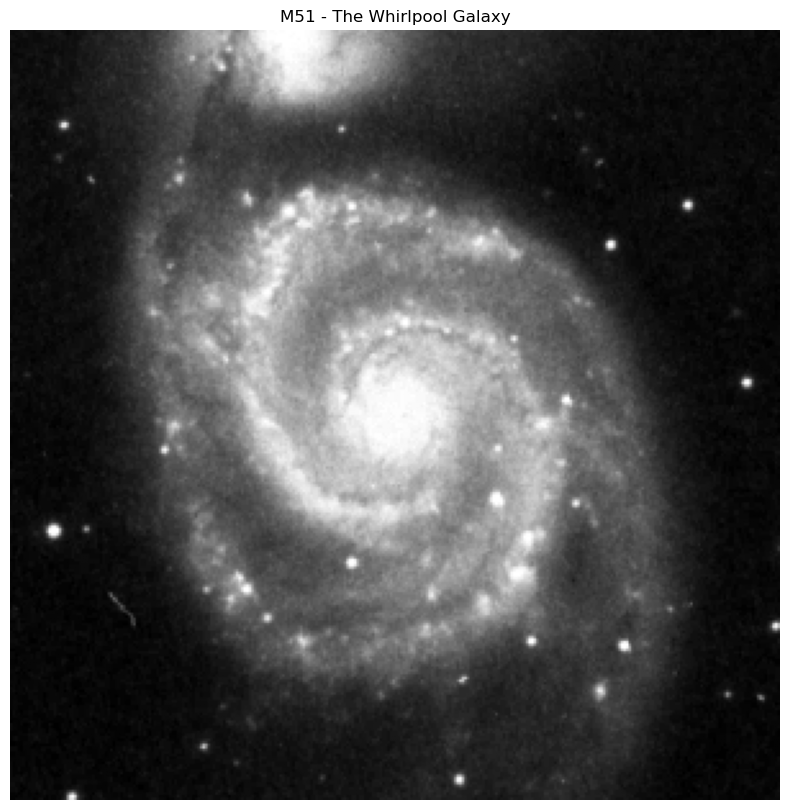

In [25]:
plt.figure(figsize=(10, 10))
plt.imshow(data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
plt.title("M51 - The Whirlpool Galaxy")
plt.axis('off')
plt.show()

In [26]:
# Take the data matrix from image
pixels = hdu.data.astype(float)
# Min-Max normalization
norm_minmax = (pixels - np.min(pixels)) / (np.max(pixels) - np.min(pixels))
# Z-Scale normalization
norm_z = (pixels - np.mean(pixels)) / np.std(pixels)
# Logarithmic normalization
norm_log = np.log(pixels - np.min(pixels)+1)
# Square root normalization
norm_sqrt = np.sqrt(pixels - np.min(pixels))

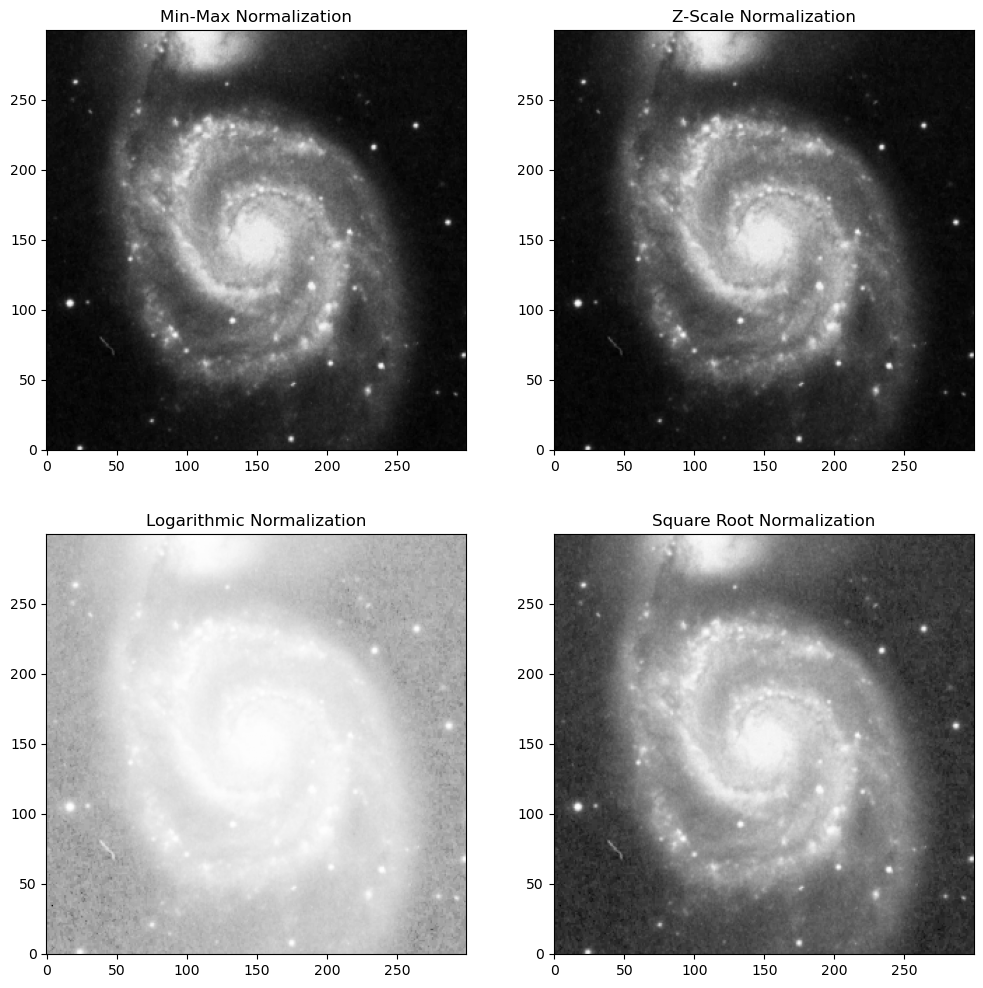

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(norm_minmax, cmap='gray', origin='lower')
axes[0, 0].set_title("Min-Max Normalization")

axes[0, 1].imshow(norm_z, cmap='gray', origin='lower')
axes[0, 1].set_title("Z-Scale Normalization")

axes[1, 0].imshow(norm_log, cmap='gray', origin='lower')
axes[1, 0].set_title("Logarithmic Normalization")

axes[1, 1].imshow(norm_sqrt, cmap='gray', origin='lower')
axes[1, 1].set_title("Square Root Normalization")

plt.show()

## Convolution: Clean Image

In [28]:
from scipy.signal import convolve2d

# Define a average 3x3 kernel
kernel_avg = np.ones((3, 3)) / 9
smooth_avg = convolve2d(norm_minmax, kernel, mode='same')

In [29]:
# Gaussian kernel
kernel_gauss = np.array([[1, 2, 1],
                            [2, 4, 2],
                            [1, 2, 1]]) / 16
smooth_gauss = convolve2d(norm_minmax, kernel_gauss, mode='same')

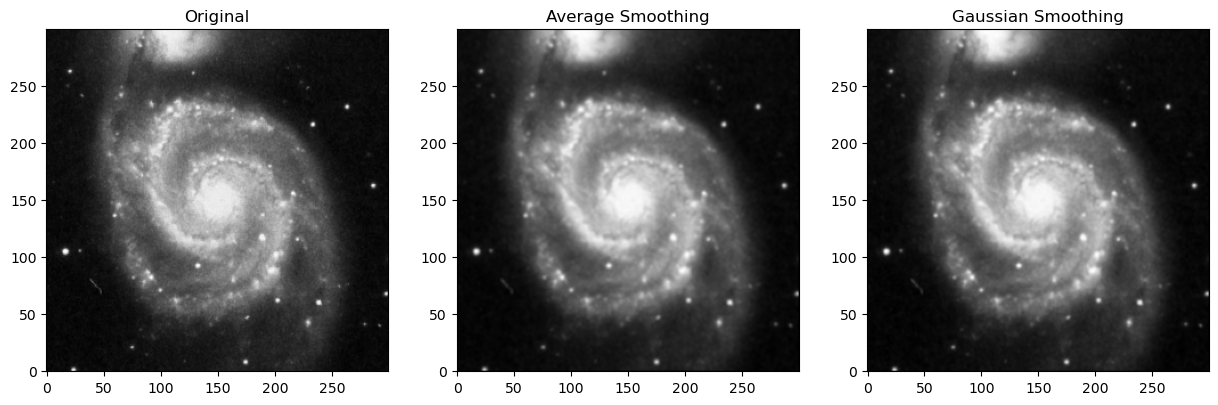

In [30]:
fig, axes = plt.subplots(1,3, figsize=(15, 5))

axes[0].imshow(norm_minmax, cmap='gray', origin='lower')
axes[0].set_title("Original")

axes[1].imshow(smooth_avg, cmap='gray', origin='lower')
axes[1].set_title("Average Smoothing")

axes[2].imshow(smooth_gauss, cmap='gray', origin='lower')
axes[2].set_title("Gaussian Smoothing")

plt.show()